# 🧬 CellPhoneDB — Cell-Cell Communication Prediction
## Assignment-1 | C2C-5 Reference | PyTorch Implementation
### Phase 1: ANN → Phase 2: ResNet
**Dataset:** `raw_data_10x.txt` + `meta_10x.txt` (CellPhoneDB maternal-fetal interface)  
**Framework:** PyTorch  
**Author:** [Your Name]


## Cell 1 — Install & Import Libraries

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', 'torchvision',
                'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn'], check=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, accuracy_score, confusion_matrix)
import warnings, time
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 256
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

PyTorch version : 2.11.0+cpu
Device          : cpu


## Cell 2 — Configuration & Hyperparameters

In [2]:
#CONFIG 
DATA_MODE    = 'real'
COUNTS_FILE  = 'raw_data_10x.txt'
META_FILE    = 'meta_10x.txt'
TOP_GENES    = 250
MAX_CELLS    = 2800
N_PER_PAIR   = 350        

# Hyperparameters
BATCH_SIZE   = 64
LR_ANN       = 1e-3
LR_CNN       = 1e-3
EPOCHS_ANN   = 80
EPOCHS_CNN   = 80         
PATIENCE     = 25
WEIGHT_DECAY = 1e-4

print('Config loaded ✓')
print(f'  TOP_GENES={TOP_GENES} | MAX_CELLS={MAX_CELLS}')
print(f'  ANN  lr={LR_ANN}  epochs={EPOCHS_ANN}')
print(f'  CNN  lr={LR_CNN}  epochs={EPOCHS_CNN}')

Config loaded ✓
  TOP_GENES=250 | MAX_CELLS=2800
  ANN  lr=0.001  epochs=80
  CNN  lr=0.001  epochs=80


## Cell 3 — Data Loading
> 

In [3]:
import os
import gc

print("Checking files...")
print(f"  Counts : {'✓' if os.path.exists(COUNTS_FILE) else '✗'} {COUNTS_FILE}")
print(f"  Meta   : {'✓' if os.path.exists(META_FILE)   else '✗'} {META_FILE}")

CELL_TYPES = ['dNK1','dNK2','dNK3','dMac1','dMac2',
              'EVT','DC1','CD8','CD4','Tregs',
              'dS1','dS2','Endo','EndoL']

KNOWN_INTERACTIONS = {
    ('EVT','dNK1'),('EVT','dNK2'),('EVT','dNK3'),
    ('EVT','dMac1'),('EVT','dMac2'),('EVT','DC1'),
    ('Endo','dNK1'),('Endo','dNK2'),('Endo','dMac1'),
    ('dS2','dNK1'),('dS2','dNK2'),('dS2','dMac1'),
    ('dMac2','CD8'),('dMac2','CD4'),('dMac2','Tregs'),
    ('DC1','CD8'),('DC1','CD4'),('DC1','Tregs'),
}

def load_synthetic():
    print('[DATA] Generating synthetic data ...')
    n_cells, n_genes = 2000, 800
    proportions = np.array([0.10,0.08,0.06,0.08,0.06,0.10,
                            0.05,0.07,0.07,0.05,0.08,0.06,0.07,0.07])
    proportions /= proportions.sum()
    labels = np.random.choice(CELL_TYPES, size=n_cells, p=proportions)
    type_means = {ct: np.random.rand(n_genes)*3 for ct in CELL_TYPES}
    expr = np.zeros((n_genes, n_cells))
    for j, ct in enumerate(labels):
        base   = type_means[ct]
        counts = np.random.negative_binomial(2, 0.4, n_genes) * base
        expr[:, j] = counts
    return expr, labels

def load_real_memory_safe():
    print('[DATA] Loading real data (memory-safe 2-pass strategy) ...')

    # Meta 
    meta_df   = pd.read_csv(META_FILE, sep='\t', index_col=0)
    label_col = meta_df.columns[0]
    print(f'  Meta shape    : {meta_df.shape}')
    print(f'  Label column  : "{label_col}"')
    print(f'  Cell types    : {meta_df[label_col].unique()}')

    # Peek at the file to understand structure
    peek = pd.read_csv(COUNTS_FILE, sep='\t', index_col=0, nrows=3)
    print(f'\n  File preview  : {peek.shape[1]} columns (cells)')
    print(f'  First col val : {peek.iloc[0,0]}  ← should be a number')
    print(f'  Index sample  : {peek.index[:3].tolist()}  ← should be gene names')

    # PASS 1: Scan variances — NO dtype forcing ─
    print(f'\n  Pass 1/2 — Scanning gene variances ...')
    gene_names, gene_vars = [], []
    CHUNK_GENES = 500

    reader = pd.read_csv(COUNTS_FILE, sep='\t', index_col=0,
                         chunksize=CHUNK_GENES,
                         low_memory=False)       
    chunk_count = 0
    for chunk in reader:
        # Drop any non-numeric columns (safety net)
        chunk = chunk.apply(pd.to_numeric, errors='coerce').dropna(how='all')
        gene_names.extend(chunk.index.tolist())
        gene_vars.extend(chunk.var(axis=1).tolist())
        chunk_count += 1
        if chunk_count % 10 == 0:
            print(f'    Scanned {len(gene_names):,} genes ...', end='\r')
        del chunk
        gc.collect()

    print(f'\n  Total genes : {len(gene_names):,}')

    #Pick top variable genes
    gene_vars  = np.array(gene_vars)
    gene_names = np.array(gene_names)
    top_idx    = np.argsort(gene_vars)[-TOP_GENES:]
    top_genes  = set(gene_names[top_idx].tolist())
    print(f'  Top {TOP_GENES} variable genes selected')

    # PASS 2: Load only top genes 
    print(f'\n  Pass 2/2 — Loading top {TOP_GENES} genes only ...')
    selected_rows = []

    reader = pd.read_csv(COUNTS_FILE, sep='\t', index_col=0,
                         chunksize=CHUNK_GENES,
                         low_memory=False)          # ← no dtype=float32
    for chunk in reader:
        keep = chunk.index.isin(top_genes)
        if keep.any():
            sub = chunk[keep].apply(pd.to_numeric, errors='coerce')
            selected_rows.append(sub)
        del chunk
        gc.collect()

    count_df = pd.concat(selected_rows)
    print(f'  Loaded shape  : {count_df.shape}  (genes × cells)')
    del selected_rows
    gc.collect()

    # Align cells
    common = meta_df.index.intersection(count_df.columns)
    print(f'  Common cells  : {len(common):,}')

    if len(common) == 0:
        print('  Trying transpose ...')
        count_df = count_df.T
        common   = meta_df.index.intersection(count_df.columns)
        print(f'  Common after transpose: {len(common):,}')

    count_df = count_df[common]
    labels   = meta_df.loc[common, label_col].values
    expr     = count_df.values.astype(np.float32)  

    print(f'\n  ✓ Expression matrix : {expr.shape}')
    print(f'  ✓ Cell types found  : {np.unique(labels)}')
    return expr, labels

# Load 
if DATA_MODE == 'real':
    expression, labels = load_real_memory_safe()
else:
    expression, labels = load_synthetic()

# Subsample
n_genes_raw, n_cells_raw = expression.shape
if n_cells_raw > MAX_CELLS:
    idx        = np.random.choice(n_cells_raw, MAX_CELLS, replace=False)
    expression = expression[:, idx]
    labels     = labels[idx]
    print(f'[DATA] Subsampled to {MAX_CELLS} cells')

print(f'\n[DATA] ✓ Ready — {expression.shape[0]} genes × {expression.shape[1]} cells')
print(f'[DATA] ✓ Labels — {np.unique(labels)}')

Checking files...
  Counts : ✓ raw_data_10x.txt
  Meta   : ✓ meta_10x.txt
[DATA] Loading real data (memory-safe 2-pass strategy) ...
  Meta shape    : (64734, 4)
  Label column  : "Fetus"
  Cell types    : ['D6' 'D7' 'D8' 'D9' 'D10' 'D11' 'D12']

  File preview  : 64734 columns (cells)
  First col val : 0  ← should be a number
  Index sample  : ['TNMD_ENSG00000000005', 'DPM1_ENSG00000000419', 'SCYL3_ENSG00000000457']  ← should be gene names

  Pass 1/2 — Scanning gene variances ...
    Scanned 30,000 genes ...
  Total genes : 31,764
  Top 250 variable genes selected

  Pass 2/2 — Loading top 250 genes only ...
  Loaded shape  : (250, 64734)  (genes × cells)
  Common cells  : 64,734

  ✓ Expression matrix : (250, 64734)
  ✓ Cell types found  : ['D10' 'D11' 'D12' 'D6' 'D7' 'D8' 'D9']
[DATA] Subsampled to 2800 cells

[DATA] ✓ Ready — 250 genes × 2800 cells
[DATA] ✓ Labels — ['D10' 'D11' 'D12' 'D6' 'D7' 'D8' 'D9']


## Cell 4 — Preprocessing & Feature Engineering

In [4]:
#Select top variable genes
gene_var = expression.var(axis=1)
top_idx  = np.argsort(gene_var)[-TOP_GENES:]
expr_sub = expression[top_idx, :]        

#Normalize — CPM → log → standardize 
col_sums = expr_sub.sum(axis=0) + 1e-9
expr_cpm = (expr_sub / col_sums) * 1e4

expr_log = np.log1p(expr_cpm)
expr_log = (expr_log - expr_log.mean()) / (expr_log.std() + 1e-8)
X_cells  = expr_log.T                 

print(f'Gene matrix shape : {X_cells.shape}')

#Inspect cell types 
unique_types = np.unique(labels)
print(f'\nCell types found in your data ({len(unique_types)}):')
for ct in unique_types:
    print(f'  "{ct}" → {np.sum(labels == ct)} cells')

type_to_idx = {ct: np.where(labels == ct)[0] for ct in unique_types}

# Create PAIRS (CONSISTENT FEATURES)
pair_X, pair_y = [], []
N_PER_PAIR = 300

# POSITIVE PAIRS (same cell type)
for ct, idx_arr in type_to_idx.items():
    if len(idx_arr) < 2:
        continue

    n = min(N_PER_PAIR, len(idx_arr))

    sA = np.random.choice(idx_arr, n, replace=True)
    sB = np.random.choice(idx_arr, n, replace=True)

    for a, b in zip(sA, sB):
        diff = np.abs(X_cells[a] - X_cells[b])   # 🔥 KEY FIX
        pair_X.append(np.concatenate([X_cells[a], X_cells[b], diff]))
        pair_y.append(1)

n_pos = len(pair_y)
print(f'Positive pairs : {n_pos}')

# NEGATIVE PAIRS (different cell types)
all_types = list(type_to_idx.keys())

neg_added = 0
max_tries = n_pos * 20
tries = 0

while neg_added < n_pos and tries < max_tries:
    tries += 1

    tA = np.random.choice(all_types)
    tB = np.random.choice(all_types)

    if tA == tB:
        continue

    a = np.random.choice(type_to_idx[tA])
    b = np.random.choice(type_to_idx[tB])

    diff = np.abs(X_cells[a] - X_cells[b])   #SAME FEATURE SIZE
    pair_X.append(np.concatenate([X_cells[a], X_cells[b], diff]))
    pair_y.append(0)

    neg_added += 1

print(f'Negative pairs : {neg_added}')

# Convert to numpy
X_all = np.array(pair_X, dtype=np.float32)
y_all = np.array(pair_y, dtype=np.float32)

print(f'Total dataset  : {X_all.shape} | Positive rate: {y_all.mean():.2f}')

#Scale
scaler = StandardScaler()
X_all  = scaler.fit_transform(X_all).astype(np.float32)

#Train / Val / Test split 
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=SEED)

INPUT_DIM = X_all.shape[1]

print(f'\nTrain={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}')
print(f'Input dimension : {INPUT_DIM}')

Gene matrix shape : (2800, 250)

Cell types found in your data (7):
  "D10" → 418 cells
  "D11" → 113 cells
  "D12" → 252 cells
  "D6" → 361 cells
  "D7" → 296 cells
  "D8" → 790 cells
  "D9" → 570 cells
Positive pairs : 1861
Negative pairs : 1861
Total dataset  : (3722, 750) | Positive rate: 0.50

Train=2688 | Val=475 | Test=559
Input dimension : 750


## Cell 5 — DataLoader Helper

In [5]:
def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    Xt = torch.tensor(X).to(DEVICE)
    yt = torch.tensor(y).unsqueeze(1).to(DEVICE)
    ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 42
Val   batches : 8
Test  batches : 9


## Cell 6 — Evaluation Helper Function

In [6]:
def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            probs = model(Xb).squeeze().cpu().numpy()
            all_probs.extend(probs if probs.ndim > 0 else [probs.item()])
            all_labels.extend(yb.squeeze().cpu().numpy())
    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'y_true'   : y_true,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

def print_metrics(m, title=''):
    print(f'\n  ── {title} ──')
    for k in ['Accuracy','Precision','Recall','F1']:
        bar = '█' * int(m[k]*25)
        print(f'  {k:<10}: {m[k]:.4f}  |{bar}')

print('evaluate_model() ready ✓')

evaluate_model() ready ✓


## Cell 7 — Training Loop Helper

In [7]:
def train_model(model, train_loader, val_loader,
                epochs, lr, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, label='Model'):
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs, eta_min=1e-6)  
    criterion = nn.BCELoss()

    history = {'train_loss':[], 'val_loss':[],
               'train_f1':[], 'val_f1':[]}
    best_val_loss = float('inf')
    best_state    = None
    pat_cnt       = 0
    t0 = time.time()

    for epoch in range(1, epochs+1):
        #  Train 
        model.train()
        t_loss, t_preds, t_labels = 0, [], []
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
            t_preds.extend((out.detach().cpu().numpy() >= 0.5).astype(int).flatten())
            t_labels.extend(yb.cpu().numpy().flatten())
        t_loss /= len(train_loader)
        t_f1    = f1_score(t_labels, t_preds, zero_division=0)

        #  Validate 
        model.eval()
        v_loss, v_preds, v_labels = 0, [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                out  = model(Xb)
                loss = criterion(out, yb)
                v_loss += loss.item()
                v_preds.extend((out.cpu().numpy() >= 0.5).astype(int).flatten())
                v_labels.extend(yb.cpu().numpy().flatten())
        v_loss /= len(val_loader)
        v_f1    = f1_score(v_labels, v_preds, zero_division=0)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_f1'].append(t_f1)
        history['val_f1'].append(v_f1)

        #  Early stopping 
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state    = {k: v.clone() for k,v in model.state_dict().items()}
            pat_cnt       = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            print(f'  Early stop at epoch {epoch}')
            break

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [{label}] Ep {epoch:>3}/{epochs} | '
                  f'TrainLoss={t_loss:.4f} | ValLoss={v_loss:.4f} | '
                  f'ValF1={v_f1:.4f}')

    model.load_state_dict(best_state)
    print(f'  Done in {time.time()-t0:.1f}s | Best ValLoss={best_val_loss:.4f}')
    return history

print('train_model() ready ✓')

train_model() ready ✓


## Cell 8 — Phase 1: ANN Model Definition
**Architecture:**  
`Input(400) → Linear(256) → BN → ReLU → Dropout(0.3)`  
`→ Linear(128) → BN → ReLU → Dropout(0.3)`  
`→ Linear(64) → BN → ReLU`  
`→ Linear(1) → Sigmoid`


In [8]:
class ANN(nn.Module):
    def __init__(self, input_dim):
        super(ANN, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

    def extract_features(self, x):
        return self.feature_extractor(x)   # ← returns 64-dim features

ann_model    = ANN(INPUT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in ann_model.parameters() if p.requires_grad)
print(ann_model)
print(f'\nTotal trainable parameters : {total_params:,}')

ANN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=750, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total trainable parameters : 234,369


## Cell 9 — Phase 1: Train ANN

In [9]:
print('='*55)
print('  PHASE 1 : Training ANN')
print('='*55)

ann_history = train_model(
    model=ann_model, train_loader=train_loader, val_loader=val_loader,
    epochs=EPOCHS_ANN, lr=LR_ANN, label='ANN'
)

  PHASE 1 : Training ANN
  [ANN] Ep   1/80 | TrainLoss=0.6345 | ValLoss=0.5965 | ValF1=0.6787
  [ANN] Ep  10/80 | TrainLoss=0.1717 | ValLoss=0.7545 | ValF1=0.7469
  [ANN] Ep  20/80 | TrainLoss=0.0914 | ValLoss=1.0560 | ValF1=0.7449
  Early stop at epoch 27
  Done in 12.1s | Best ValLoss=0.5626


## Cell 10 — Phase 1: Evaluate ANN (4 Metrics)

In [10]:
ann_metrics = evaluate_model(ann_model, test_loader)
print_metrics(ann_metrics, 'ANN — Test Set Results')

cm = confusion_matrix(ann_metrics['y_true'], ann_metrics['y_pred'])
print('\n  Confusion Matrix:')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}  TP={cm[1,1]}')


  ── ANN — Test Set Results ──
  Accuracy  : 0.6887  |█████████████████
  Precision : 0.6721  |████████████████
  Recall    : 0.7348  |██████████████████
  F1        : 0.7021  |█████████████████

  Confusion Matrix:
  TN=180  FP=100
  FN=74  TP=205


## Cell 11 — Phase 1: Plot ANN Training Curves + Confusion Matrix

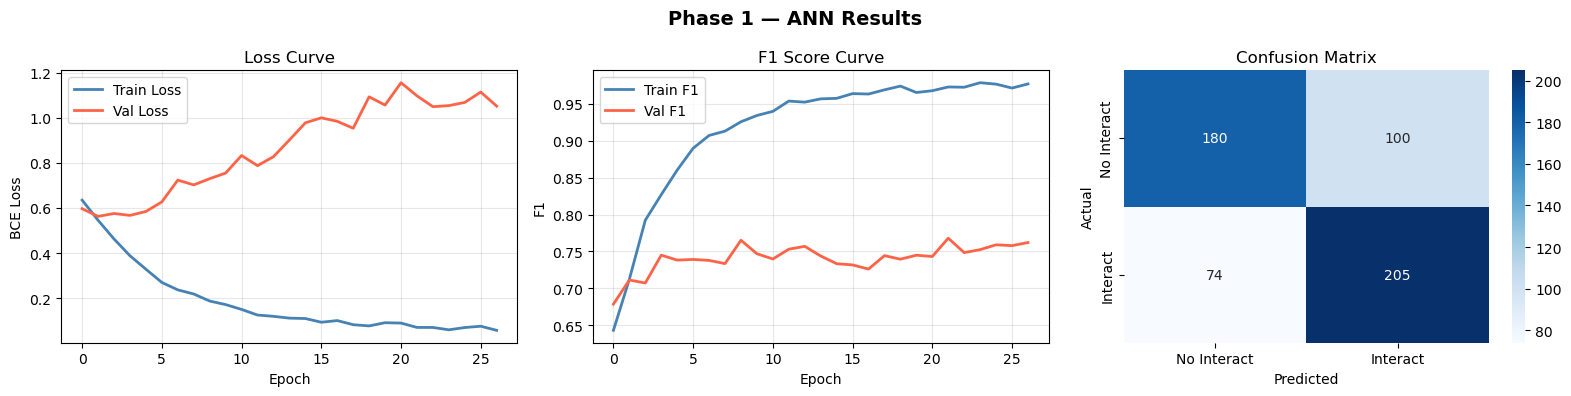

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Phase 1 — ANN Results', fontsize=14, fontweight='bold')

axes[0].plot(ann_history['train_loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(ann_history['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ann_history['train_f1'], label='Train F1', color='steelblue', lw=2)
axes[1].plot(ann_history['val_f1'],   label='Val F1',   color='tomato',    lw=2)
axes[1].set_title('F1 Score Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(ann_metrics['y_true'], ann_metrics['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Interact','Interact'],
            yticklabels=['No Interact','Interact'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('ann_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Phase 1: Metrics Bar Chart

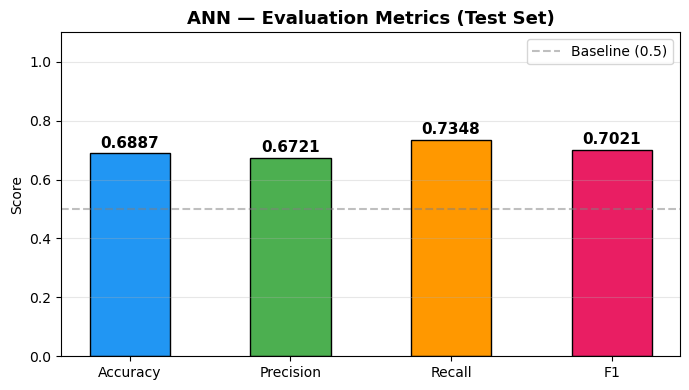

In [12]:
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1']
metrics_values = [ann_metrics[m] for m in metrics_names]
colors         = ['#2196F3','#4CAF50','#FF9800','#E91E63']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics_names, metrics_values, color=colors, width=0.5, edgecolor='black')
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('ANN — Evaluation Metrics (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (0.5)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ann_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
#  Extract 64-dim features from trained ANN 
def extract_features(model, X):
    model.eval()
    Xt = torch.tensor(X).to(DEVICE)
    with torch.no_grad():
        feats = model.extract_features(Xt).cpu().numpy()
    return feats

print('Extracting ANN features...')
X_train_feat = extract_features(ann_model, X_train)
X_val_feat   = extract_features(ann_model, X_val)
X_test_feat  = extract_features(ann_model, X_test)

print(f'Train features shape : {X_train_feat.shape}')  # (n, 64)
print(f'Val   features shape : {X_val_feat.shape}')
print(f'Test  features shape : {X_test_feat.shape}')

#  New DataLoaders for CNN using ANN features 
CNN_INPUT_DIM  = X_train_feat.shape[1]   # 64

train_loader_cnn = make_loader(X_train_feat, y_train, shuffle=True)
val_loader_cnn   = make_loader(X_val_feat,   y_val,   shuffle=False)
test_loader_cnn  = make_loader(X_test_feat,  y_test,  shuffle=False)

print(f'\nCNN Input dim    : {CNN_INPUT_DIM}')
print(f'Train CNN batches: {len(train_loader_cnn)}')
print('ANN features ready for CNN ✓')

Extracting ANN features...
Train features shape : (2688, 64)
Val   features shape : (475, 64)
Test  features shape : (559, 64)

CNN Input dim    : 64
Train CNN batches: 42
ANN features ready for CNN ✓


### VGGNet

In [14]:
class VGGNet1D(nn.Module):
    def __init__(self, input_dim, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool1d(2, 2),
            # Block 2
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool1d(2, 2),
            # Block 3
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool1d(2, 2),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),   nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        x = self.gap(x)
        return self.head(x)

cnn_model    = VGGNet1D(CNN_INPUT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(cnn_model)
print(f'\nTotal trainable parameters : {total_params:,}')

VGGNet1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU(inplace=True)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU(inplace=True)
    (7): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): ReLU(inplace=True)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): ReLU(inplace=True)
    (12): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): ReLU(inplace=True)
    (14): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): AdaptiveAvgPool1d(output_size=1)
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(

In [15]:
print('='*55)
print('  PHASE 2 : Training VGGNet-1D on ANN Features')
print('='*55)

cnn_history = train_model(
    model=cnn_model, train_loader=train_loader_cnn, val_loader=val_loader_cnn,
    epochs=EPOCHS_CNN, lr=LR_CNN, label='VGGNet'
)

  PHASE 2 : Training VGGNet-1D on ANN Features
  [VGGNet] Ep   1/80 | TrainLoss=0.6936 | ValLoss=0.6931 | ValF1=0.6676
  [VGGNet] Ep  10/80 | TrainLoss=0.6936 | ValLoss=0.6932 | ValF1=0.0000
  [VGGNet] Ep  20/80 | TrainLoss=0.6931 | ValLoss=0.6931 | ValF1=0.6676
  Early stop at epoch 27
  Done in 39.3s | Best ValLoss=0.6931


In [16]:
cnn_metrics = evaluate_model(cnn_model, test_loader_cnn)
print_metrics(cnn_metrics, 'VGGNet-1D — Test Set Results')

cm = confusion_matrix(cnn_metrics['y_true'], cnn_metrics['y_pred'])
print('\n  Confusion Matrix:')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}  TP={cm[1,1]}')


  ── VGGNet-1D — Test Set Results ──
  Accuracy  : 0.4991  |████████████
  Precision : 0.4991  |████████████
  Recall    : 1.0000  |█████████████████████████
  F1        : 0.6659  |████████████████

  Confusion Matrix:
  TN=0  FP=280
  FN=0  TP=279


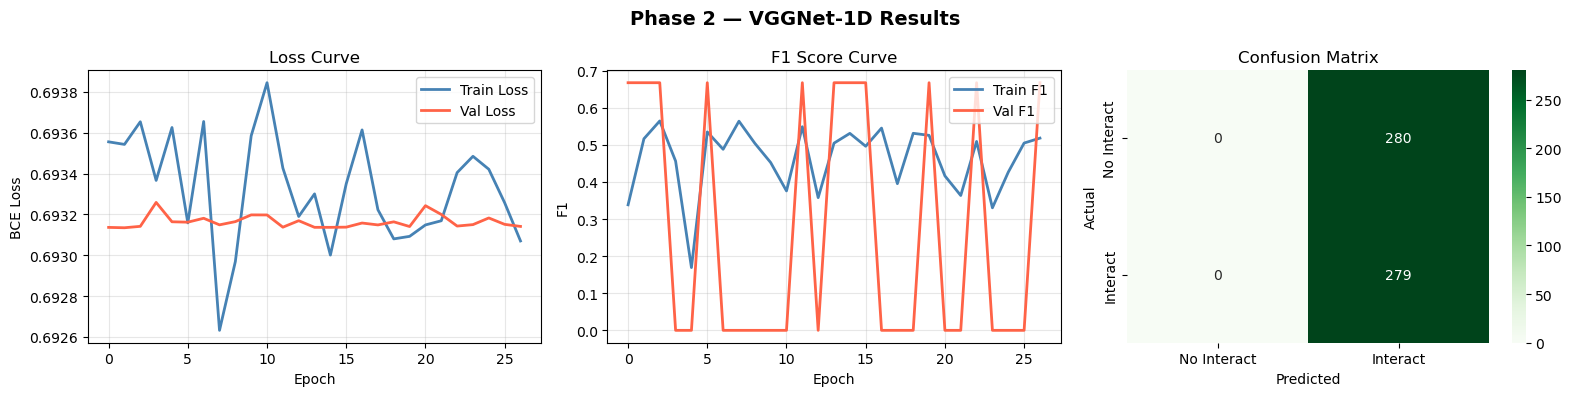

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Phase 2 — VGGNet-1D Results', fontsize=14, fontweight='bold')

axes[0].plot(cnn_history['train_loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(cnn_history['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(cnn_history['train_f1'], label='Train F1', color='steelblue', lw=2)
axes[1].plot(cnn_history['val_f1'],   label='Val F1',   color='tomato',    lw=2)
axes[1].set_title('F1 Score Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(cnn_metrics['y_true'], cnn_metrics['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['No Interact','Interact'],
            yticklabels=['No Interact','Interact'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('vggnet_results.png', dpi=150, bbox_inches='tight')
plt.show()

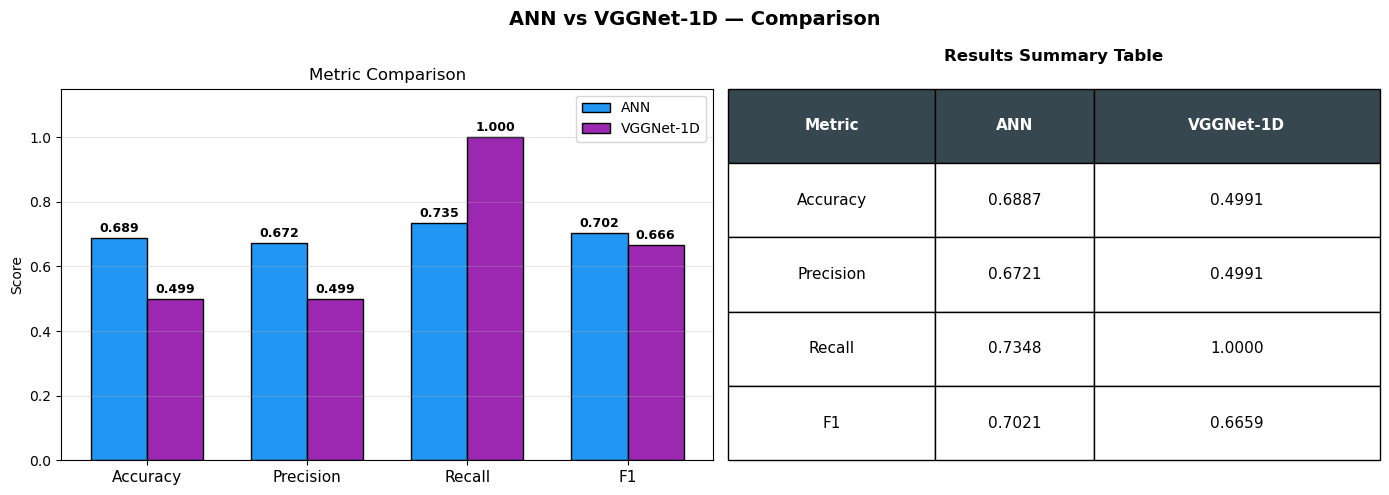


  ANN vs VGGNet RESULTS
  Metric              ANN     VGGNet
  ----------------------------------
  Accuracy         0.6887     0.4991
  Precision        0.6721     0.4991
  Recall           0.7348     1.0000
  F1               0.7021     0.6659


In [18]:
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1']
ann_vals      = [ann_metrics[m] for m in metric_names]
cnn_vals      = [cnn_metrics[m] for m in metric_names]

x     = np.arange(len(metric_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN vs VGGNet-1D — Comparison', fontsize=14, fontweight='bold')

b1 = axes[0].bar(x - width/2, ann_vals, width, label='ANN',       color='#2196F3', edgecolor='black')
b2 = axes[0].bar(x + width/2, cnn_vals, width, label='VGGNet-1D', color='#9C27B0', edgecolor='black')
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names, fontsize=11)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('Score')
axes[0].set_title('Metric Comparison'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].axis('off')
table_data = [['Metric','ANN','VGGNet-1D']]
for m, av, cv in zip(metric_names, ann_vals, cnn_vals):
    table_data.append([m, f'{av:.4f}', f'{cv:.4f}'])
tbl = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                    cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.auto_set_column_width([0,1,2])
for j in range(3):
    tbl[0,j].set_facecolor('#37474F')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
axes[1].set_title('Results Summary Table', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('vggnet_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print('  ANN vs VGGNet RESULTS')
print('='*50)
print(f'  {"Metric":<12} {"ANN":>10} {"VGGNet":>10}')
print('  ' + '-'*34)
for m, av, cv in zip(metric_names, ann_vals, cnn_vals):
    print(f'  {m:<12} {av:>10.4f} {cv:>10.4f}')
print('='*50)

vggnet_metrics = cnn_metrics.copy()

In [22]:
import json, os
notebook_name = 'CellPhoneDB_ANN_VGGNet'   

results = {
    'notebook' : notebook_name,
    'ann'      : {
        'Accuracy' : float(ann_metrics['Accuracy']),
        'Precision': float(ann_metrics['Precision']),
        'Recall'   : float(ann_metrics['Recall']),
        'F1'       : float(ann_metrics['F1']),
    },
    'cnn'      : {
        'model'    : 'LeNet',              
        'Accuracy' : float(cnn_metrics['Accuracy']),
        'Precision': float(cnn_metrics['Precision']),
        'Recall'   : float(cnn_metrics['Recall']),
        'F1'       : float(cnn_metrics['F1']),
    }
}

with open(f'{notebook_name}_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'✓ Saved {notebook_name}_results.json')
print(json.dumps(results, indent=2))

✓ Saved CellPhoneDB_ANN_VGGNet_results.json
{
  "notebook": "CellPhoneDB_ANN_VGGNet",
  "ann": {
    "Accuracy": 0.6887298747763864,
    "Precision": 0.6721311475409836,
    "Recall": 0.7347670250896058,
    "F1": 0.702054794520548
  },
  "cnn": {
    "model": "LeNet",
    "Accuracy": 0.4991055456171735,
    "Precision": 0.4991055456171735,
    "Recall": 1.0,
    "F1": 0.665871121718377
  }
}
